# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [8]:
#Pandas is used for tabular data analysis.
import pandas as pd

#NumPy(Numerical Python) is used for fast numerical computing, scientific computing, and working with large multi-dimensional arrays and metrices.
import numpy as np

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Determine Dataset Dimensions
df.shape

(41188, 21)

In [6]:
# Display Column Names
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [ ]:

# Check for missing values and data types
# For missing Values
df.isna().sum() # All columns returned a missing-value count of zero.



age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [ ]:
# For Data Types
df.dtypes


<bound method DataFrame.info of        age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

         contact mo

In [3]:
# For a more complete structural information:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [2]:
# Numberical Descriptive Statistics
# For Numerical Variables
numerical_columns=df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [8]:
# The Five-Number Summary
five_number_summary=df[numerical_columns].describe().T[
    ["min","25%","50%","75%","max"]
]
five_number_summary

,min,25%,50%,75%,max
age,17.000,32.000,38.000,47.000,98.000
duration,0.000,102.000,180.000,319.000,4918.000
campaign,1.000,1.000,2.000,3.000,56.000
pdays,0.000,999.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,0.000,7.000
emp.var.rate,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,0.634,1.344,4.857,4.961,5.045
nr.employed,4963.600,5099.100,5191.000,5228.100,5228.100


In [10]:
# Interquartile Range (IQR)
iqr_summary=pd.DataFrame({
    "Q1": df[numerical_columns].quantile(0.25),
    "Q3": df[numerical_columns].quantile(0.75)
})

iqr_summary["IQR"] = (
    iqr_summary["Q3"] - iqr_summary["Q1"]
)

iqr_summary

,Q1,Q3,IQR
age,32.000,47.000,15.000
duration,102.000,319.000,217.000
campaign,1.000,3.000,2.000
pdays,999.000,999.000,0.000
previous,0.000,0.000,0.000
emp.var.rate,-1.800,1.400,3.200
cons.price.idx,93.075,93.994,0.919
cons.conf.idx,-42.700,-36.400,6.300
euribor3m,1.344,4.961,3.617
nr.employed,5099.100,5228.100,129.000


In [12]:
# For Categorical Variables
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns

C:\Users\Ravindra Pal\AppData\Local\Temp\ipykernel_12524\280625080.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [6]:
# Identify the Target Variables
df["y"].unique

<bound method Series.unique of 0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: y, Length: 41188, dtype: str>

In [2]:
# Count Each Target Class
target_counts = df["y"].value_counts()
target_counts

y
no     36548
yes     4640
Name: count, dtype: int64

In [3]:
#Calculate Target Percentages
target_percentage = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
)
target_percentage

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [ ]:
# Click Explicit Missing Values
missing_values = df.isna().sum()

missing_values

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
# Count unknown Values
unknown_counts = (
    df.astype("object")
      .apply(lambda column: column.eq("unknown").sum())
)

unknown_counts[unknown_counts>0]

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

In [4]:
# Check Duplicate Records
dulicate_count = df.duplicated().sum()
dulicate_count

np.int64(12)

In [15]:
# Frequency Analysis of Categorical Varibles
#for column in categorical_columns:
 #   print(df[column].value_counts())

# For percentages:
for column in categorical_columns:
    frequency_table = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="count")
    )   

    frequency_table["percentage"] = (
        frequency_table["count"]
        /len(df)
        *100
    ) 

    print(frequency_table)




              job  count  percentage
0          admin.  10422   25.303486
1     blue-collar   9254   22.467709
2      technician   6743   16.371273
3        services   3969    9.636302
4      management   2924    7.099155
5         retired   1720    4.175974
6    entrepreneur   1456    3.535010
7   self-employed   1421    3.450034
8       housemaid   1060    2.573565
9      unemployed   1014    2.461882
10        student    875    2.124405
11        unknown    330    0.801204
    marital  count  percentage
0   married  24928   60.522482
1    single  11568   28.085850
2  divorced   4612   11.197436
3   unknown     80    0.194231
             education  count  percentage
0    university.degree  12168   29.542585
1          high.school   9515   23.101389
2             basic.9y   6045   14.676605
3  professional.course   5243   12.729436
4             basic.4y   4176   10.138875
5             basic.6y   2292    5.564728
6              unknown   1731    4.202680
7           illiterate     1

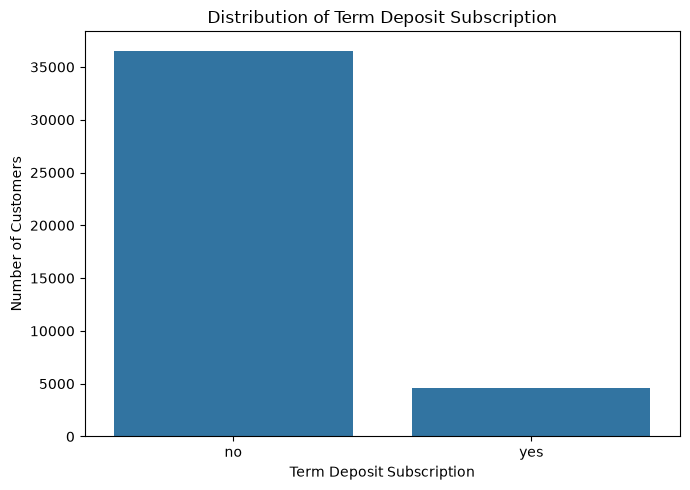

In [6]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
# Visualize the Target Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='y'
)

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


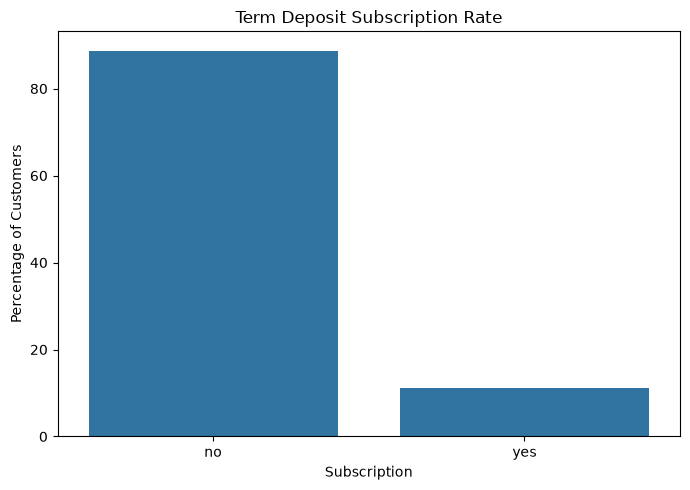

In [10]:
# Percentage Visualization
target_percentage = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Term Deposit Subscription Rate")
plt.xlabel("Subscription")
plt.ylabel("Percentage of Customers")

plt.tight_layout()
plt.show()


In [13]:
# Create a Clean Target Summary Table
target_summary = (
    df["y"]
    .value_counts()
    .rename_axis("subscription")
    .reset_index(name="count")
)

target_summary["percentage"] = (
    target_summary["count"]
    / len(df)
    *100
)

target_summary

,subscription,count,percentage
0,no,36548,88.734583
1,yes,4640,11.265417


In [15]:
# Business Interpretation
# The target variable represents the outcome of the marketing campaign.
# The descriptive analysis shows:
# 36,548 customers did not subscribe
# 4640 customers subscribe
# Therefore, the observed dataset contains substantially more non-subscribers than subscribers.
# The ration of non-subscribes to subscribes is approximately 7.88:1.

In [16]:
# Target Distribution by Customer Characteristics
job_target = pd.crosstab(
    df["job"],
    df["y"]
)

job_target

y,no,yes
job,,
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323
student,600,275


In [20]:
# Verify Target Completeness
df["y"].isna().sum()

np.int64(0)

In [21]:
# Verify Unexpected Target Categories
df["y"].value_counts(dropna=False)

y
no     36548
yes     4640
Name: count, dtype: int64

In [3]:
# Numberical Descriptive Statistics
# For Numerical Variables
numerical_columns=df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [4]:

# Calculate the Correlation Matrix
correlation_matrix = df[numerical_columns].corr()

correlation_matrix



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


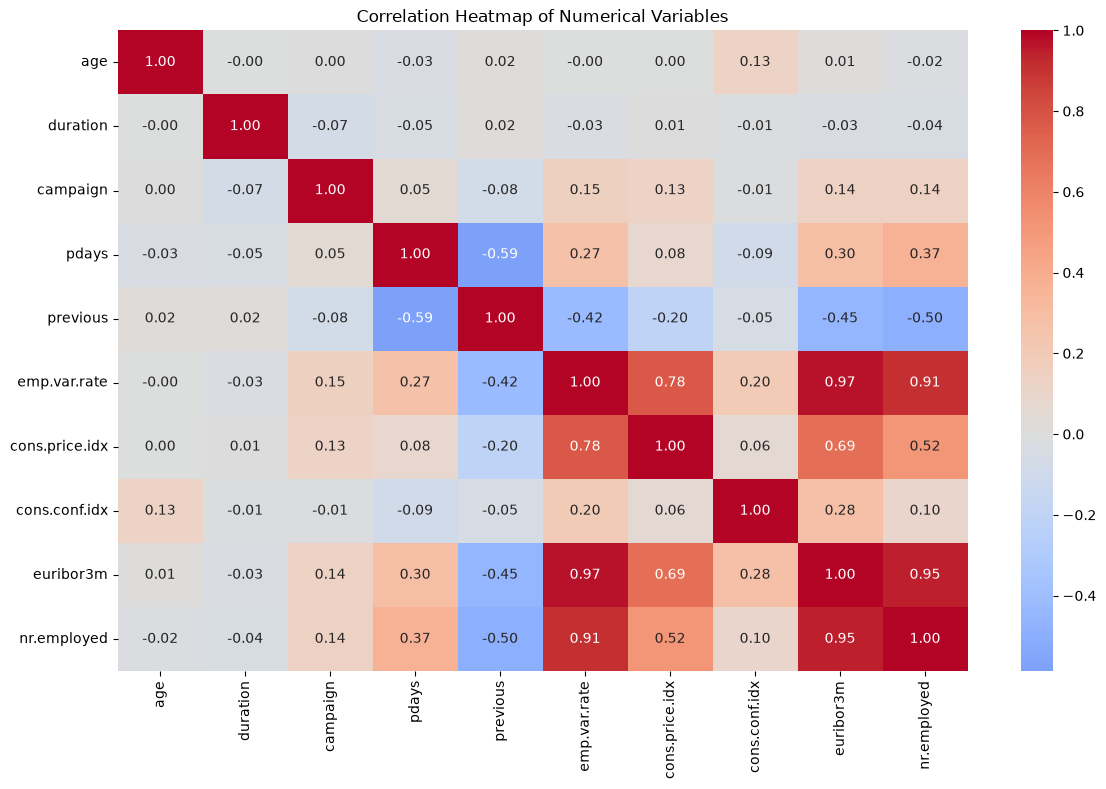

In [7]:
# The correlation Heatmap
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [9]:
# Correlation Matrix Extraction
correlation_matrix = df[numerical_columns].corr()

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

upper_triangle

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,NaN,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,NaN,NaN,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,NaN,NaN,NaN,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,NaN,NaN,NaN,NaN,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,NaN,NaN,NaN,NaN,NaN,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,NaN,NaN,NaN,NaN,NaN,NaN,0.775334,0.196041,0.972245,0.906970
cons.price.idx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.058986,0.688230,0.522034
cons.conf.idx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.277686,0.100513
euribor3m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.945154
nr.employed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- The dataset includes customer demographics and contact details, which can be useful for segmentation.
- A majority of customers do not subscribe to term deposits, indicating an imbalanced dataset.
- Further preprocessing, feature engineering, and modeling would be the next steps for predictive analysis.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
